# Import Libraries

In [36]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer
from transformers import BertTokenizer
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import os
import pickle

# Load Dataset

In [4]:
df = pd.read_csv('Reddit_Data.csv')
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


<Axes: xlabel='category'>

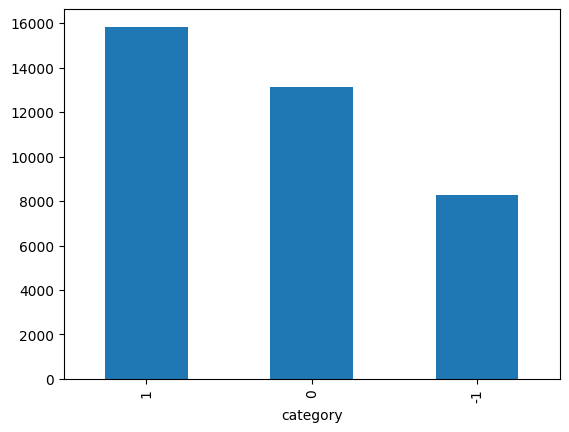

In [5]:
df['category'].value_counts().plot(kind='bar')

0 -> Neutral Comment,
1 -> Postive Comment,
-1 -> Negative Comment

# Pre-processing Data

In [5]:
X = df['clean_comment']
y = df['category']
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [6]:
stop_words = set(stopwords.words('english'))
stemmer = SnowballStemmer('english')

In [7]:
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
        
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word not in stop_words]
    stemmed_tokens = [stemmer.stem(word) for word in filtered_tokens]
    
    return ' '.join(stemmed_tokens)

In [8]:
X_train_clean = X_train.apply(preprocess_text)
X_val_clean = X_val.apply(preprocess_text)
X_test_clean = X_test.apply(preprocess_text)

X_train.head()

14703                    only sisodia from aap make sense 
14625             dear god the day ban feels like forever 
36291    this was known long time back there also scree...
7792      live suburb near mumbai roughly mins away its...
5135     vote brigading but there are other vote brigad...
Name: clean_comment, dtype: object

In [9]:
X_train_clean.head()

14703                                sisodia aap make sens
14625                     dear god day ban feel like forev
36291    known long time back also screenshot aap cell ...
7792     live suburb near mumbai rough min away small v...
5135     vote brigad vote brigad happen everi day cours...
Name: clean_comment, dtype: object

In [10]:
X_train_list = [str(text) for text in X_train_clean]
X_val_list = [str(text) for text in X_val_clean]
X_test_list = [str(text) for text in X_test_clean]

In [11]:
vocab_size = 30000 
seq_len = 100  

In [12]:
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_list)

In [13]:
train_sequences = tokenizer.texts_to_sequences(X_train_list)
val_sequences = tokenizer.texts_to_sequences(X_val_list)
test_sequences = tokenizer.texts_to_sequences(X_test_list)

In [14]:
tokens_train = pad_sequences(train_sequences, maxlen=seq_len, padding='post', truncating='post')
tokens_val = pad_sequences(val_sequences, maxlen=seq_len, padding='post', truncating='post')
tokens_test = pad_sequences(test_sequences, maxlen=seq_len, padding='post', truncating='post')

In [15]:
tokens_train.shape

(29799, 100)

In [16]:
X_train.shape

(29799,)

# Create Dataset

In [17]:
y_train_mapped = y_train + 1
y_val_mapped = y_val + 1
y_test_mapped = y_test + 1

In [18]:
labels_train = tf.keras.utils.to_categorical(y_train_mapped, num_classes=3)
labels_val = tf.keras.utils.to_categorical(y_val_mapped, num_classes=3)
labels_test = tf.keras.utils.to_categorical(y_test_mapped, num_classes=3)

In [19]:
batch_size = 32

In [20]:
train_dataset = tf.data.Dataset.from_tensor_slices((tokens_train, labels_train))
train_dataset = train_dataset.shuffle(10000).batch(batch_size, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

In [21]:
val_dataset = tf.data.Dataset.from_tensor_slices((tokens_val, labels_val))
val_dataset = val_dataset.batch(batch_size, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

In [22]:
test_dataset = tf.data.Dataset.from_tensor_slices((tokens_test, labels_test))
test_dataset = test_dataset.batch(batch_size, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

# Modeling

In [23]:
input_sequence = layers.Input(shape=(seq_len,), dtype=tf.int32, name="input_sequence")

In [24]:
embedding_dim = 128
embedding = layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=False)(input_sequence)

In [25]:
flatten = layers.Flatten()(embedding)
dense = layers.Dense(32, activation='relu')(flatten)
dropout = layers.Dropout(0.3)(dense)

In [26]:
output = layers.Dense(3, activation='softmax')(dropout)

In [32]:
model = tf.keras.Model(inputs=input_sequence, outputs=output)

In [33]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [34]:
epochs = 3
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs
)

Epoch 1/3
931/931 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8492 - loss: 0.4376 - val_accuracy: 0.7923 - val_loss: 0.5617
Epoch 2/3
931/931 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8858 - loss: 0.3527 - val_accuracy: 0.8044 - val_loss: 0.5394
Epoch 3/3
931/931 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9115 - loss: 0.2836 - val_accuracy: 0.8031 - val_loss: 0.5429


In [37]:
folder_path = "saved_models/"
os.makedirs(folder_path, exist_ok=True)

In [39]:
model_path = folder_path + "model.keras"
model.save(model_path)

In [40]:
tokenizer_path = folder_path + "tokenizer.pkl"
with open(tokenizer_path, 'wb') as file:
    pickle.dump(tokenizer, file)

# Model Evaluation

In [30]:
loss, accuracy = model.evaluate(train_dataset)
print(f"\nTrain set accuracy: {accuracy * 100:.2f}%")

931/931 ━━━━━━━━━━━━━━━━━━━━ 1s 801us/step - accuracy: 0.8549 - loss: 0.4404

Train set accuracy: 85.49%


In [31]:
loss, accuracy = model.evaluate(test_dataset)
print(f"\nTest set accuracy: {accuracy * 100:.2f}%")

116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 631us/step - accuracy: 0.7756 - loss: 0.5728

Test set accuracy: 77.56%
